# Pandas Practice: Bike Share Trip Data

This notebook gives you practice using Pandas on a messier, more realistic dataset. You'll work with February 2014 trip data from a bike share scheme, cleaning column names, exploring patterns, filtering, grouping, and creating visualisations. A good data scientist doesn't always invent solutions from scratch; knowing where to look and how to adapt existing code is a core skill. If you get stuck, [Sebastian Raschka's Pandas tips](https://nbviewer.jupyter.org/github/rasbt/python_reference/blob/master/tutorials/things_in_pandas.ipynb) and the [Pandas documentation](https://pandas.pydata.org/docs/) are excellent references.

---

<center><img src="../assets/nextbike_bike_rental_berlin.jpg" width="800"/></center>

In [1]:
# --- Starter code: run this cell first ---
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/bike_share_201402_trip_data.csv")
df.head()

,Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscription Type,Zip Code
0,4576,63,8/29/2013 14:13,South Van Ness at Market,66,8/29/2013 14:14,South Van Ness at Market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,San Jose City Hall,10,8/29/2013 14:43,San Jose City Hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,Mountain View City Hall,27,8/29/2013 10:17,Mountain View City Hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,San Jose City Hall,10,8/29/2013 11:30,San Jose City Hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,South Van Ness at Market,66,8/29/2013 12:04,Market at 10th,67,319,Subscriber,94103


## Part 1: Cleaning and Exploring

### Challenge 1: How many trips are in the dataset?

Find the number of observations (rows) in the DataFrame.

In [7]:
# YOUR CODE HERE
rows = df.shape[0]
print(f'Number of rows: {rows}')

# Number of observations (rows) in the dataset
len(df)

df['Trip ID'].nunique()

Number of rows: 144015


144015

### Challenge 2: Make the column names Pythonic

Rename all columns so they are:
- **Lowercase**
- Spaces replaced with `_`
- `#` replaced with `num`

Print the updated column names to verify.

In [8]:
# YOUR CODE HERE
# Build the new names with chained string replacements, then assign them back.
# Order matters: replace "#" before lowercasing is fine here since "#" has no case.
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("#", "num")

# Print the updated names to verify
print(df.columns.tolist())

['trip_id', 'duration', 'start_date', 'start_station', 'start_terminal', 'end_date', 'end_station', 'end_terminal', 'bike_num', 'subscription_type', 'zip_code']


---

## Part 2: Subscription Analysis

### Challenge 3: Subscription types

How many types of subscription are there? What are they?

In [13]:
# YOUR CODE HERE
# How many distinct subscription types, and what are they?
print("Number of types:", df["subscription_type"].nunique())
print("Types:", df["subscription_type"].unique())

Number of types: 2
Types: <StringArray>
['Subscriber', 'Customer']
Length: 2, dtype: str


### Challenge 4: Frequency of each subscription type

How many trips were made by each subscription type?

In [14]:
# YOUR CODE HERE
df.subscription_type.value_counts()

subscription_type
Subscriber    113647
Customer       30368
Name: count, dtype: int64

### Challenge 5: Visualise subscription frequency, pie chart

Plot the frequency of each subscription type as a pie chart.

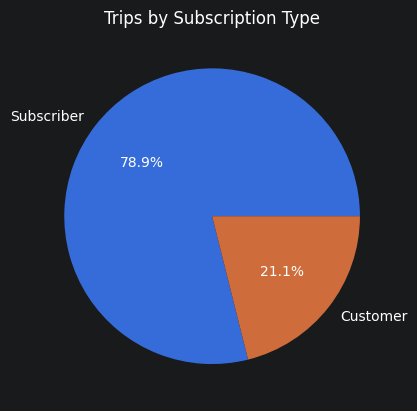

In [15]:
# YOUR CODE HERE
# Reuse the value_counts result and plot it directly as a pie chart
subscription_counts = df["subscription_type"].value_counts()
subscription_counts.plot(kind="pie", autopct="%1.1f%%", ylabel="")
plt.title("Trips by Subscription Type")
plt.show()

### Challenge 6: Visualise subscription frequency, bar chart

Plot the same data as a bar chart.

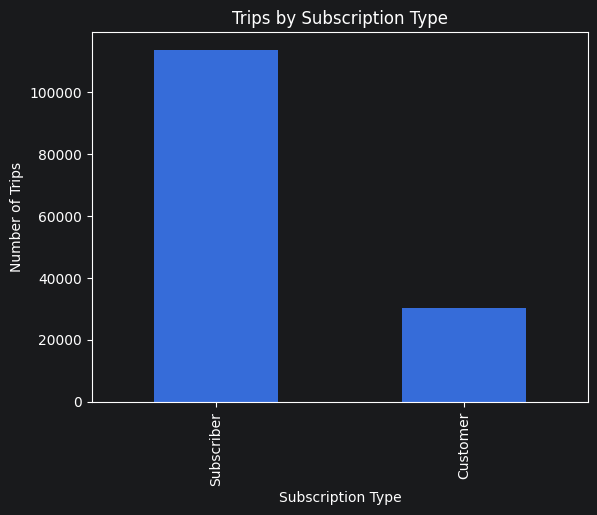

In [18]:
# YOUR CODE HERE
# Same counts, shown as a bar chart for easier comparison of exact values
subscription_counts = df["subscription_type"].value_counts()
subscription_counts.plot(kind="bar")
plt.title("Trips by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Number of Trips")
plt.show()

---

## Part 3: Station Analysis

### Challenge 7: Top 10 most popular start stations

Which 10 start stations appear most frequently in the data?

In [21]:
# YOUR CODE HERE
df["start_station"].value_counts().head(10)

start_station
San Francisco Caltrain (Townsend at 4th)         9838
Harry Bridges Plaza (Ferry Building)             7343
Embarcadero at Sansome                           6545
Market at Sansome                                5922
Temporary Transbay Terminal (Howard at Beale)    5113
Market at 4th                                    5030
2nd at Townsend                                  4987
San Francisco Caltrain 2 (330 Townsend)          4976
Steuart at Market                                4913
Townsend at 7th                                  4493
Name: count, dtype: int64

### Challenge 8: 10 least popular end stations

Which 10 end stations appear least often?

In [23]:
# YOUR CODE HERE
df["end_station"].value_counts().tail(10)

end_station
Broadway St at Battery St           205
Redwood City Medical Center         178
Castro Street and El Camino Real    129
Redwood City Public Library         117
San Mateo County Center             106
Franklin at Maple                    93
San Antonio Shopping Center          93
Broadway at Main                     56
San Jose Government Center           23
Mezes Park                            5
Name: count, dtype: int64

### Challenge 9: Cross-tabulation of start stations by subscription type

Create a table that shows the count of trips for each `start_station` segmented by `subscription_type`, including row and column totals (subtotals).

> Hint: look up `pd.crosstab()` in the documentation.

In [26]:
# YOUR CODE HERE
# pd.crosstab counts trips per start_station x subscription_type.
# margins=True adds the "All" row and column totals (subtotals).
pd.crosstab(df["start_station"], df["subscription_type"], margins=True)

subscription_type,Customer,Subscriber,All
start_station,,,
2nd at Folsom,427,3349,3776
2nd at South Park,535,3923,4458
2nd at Townsend,882,4105,4987
5th at Howard,606,2029,2635
Adobe on Almaden,75,260,335
...,...,...,...
Townsend at 7th,518,3975,4493
University and Emerson,328,106,434
Washington at Kearney,561,911,1472


---

## Part 4: Trip Duration

### Challenge 10: Explore duration

What unit do you think the `duration` column uses? Find the shortest and longest trips. How many trips are as short as the minimum?

In [27]:
# YOUR CODE HERE
# Duration values are large integers, which suggests seconds rather than minutes.
print("Shortest trip:", df["duration"].min())
print("Longest trip:", df["duration"].max())

# How many trips are exactly at the minimum duration?
shortest = df["duration"].min()
print("Trips at the minimum:", (df["duration"] == shortest).sum())

Shortest trip: 60
Longest trip: 722236
Trips at the minimum: 17


### Challenge 11: Define and count "long" trips

Define what you consider a "long" trip (justify your threshold). How many trips meet that definition? What might explain the very long durations?

In [28]:
# YOUR CODE HERE
# A normal city bike trip is short, so treat anything over 1 hour (3600 seconds)
# as a "long" trip. Comparing the column to the threshold returns a boolean Series,
# and summing it counts the True values.
long_threshold = 3600
print("Long trips (over 1 hour):", (df["duration"] > long_threshold).sum())

# The very long durations are likely bikes that were not docked properly,
# so the rental kept running.
df[df["duration"] > long_threshold]["duration"].describe()

Long trips (over 1 hour): 5695


count      5695.000000
mean      15984.354697
std       29799.489948
min        3601.000000
25%        5518.500000
50%        8688.000000
75%       15662.500000
max      722236.000000
Name: duration, dtype: float64

### Challenge 12: Plot the duration distribution

Create a histogram of the `duration` column. Does it give clear insights? If not, filter to a more meaningful range and re-plot.

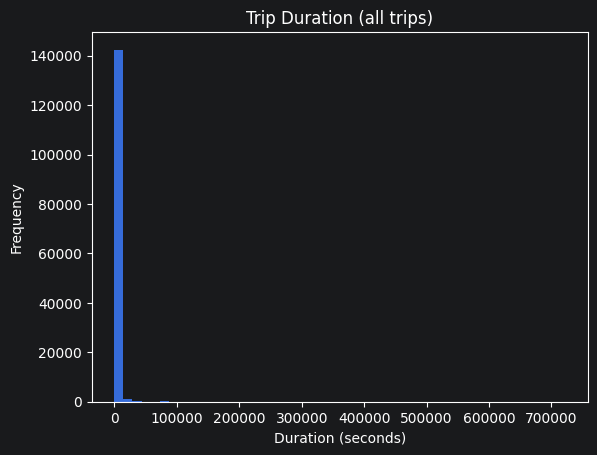

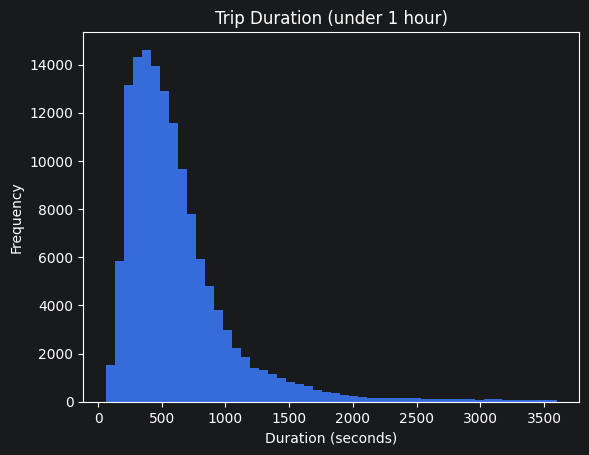

In [29]:
# YOUR CODE HERE
# A raw histogram is dominated by a few extreme outliers, so the bars are unreadable.
df["duration"].plot(kind="hist", bins=50)
plt.title("Trip Duration (all trips)")
plt.xlabel("Duration (seconds)")
plt.show()

# Filter to trips under 1 hour to see the meaningful shape of the distribution
short_trips = df[df["duration"] < 3600]
short_trips["duration"].plot(kind="hist", bins=50)
plt.title("Trip Duration (under 1 hour)")
plt.xlabel("Duration (seconds)")
plt.show()

---

## Part 5: Data Cleaning (Advanced)

### Challenge 13: Normalise station names

The product team wants all station names to be lowercase with underscores as separators.

Example: `South Van Ness at Market` → `south_van_ness_at_market`

Apply this transformation to both the `start_station` and `end_station` columns.

> **Do NOT use a for loop.** Use a vectorised Pandas string method instead, it will be much faster.

In [30]:
# YOUR CODE HERE
# Vectorised string methods run over the whole column at C speed, no Python loop.
df["start_station"] = df["start_station"].str.lower().str.replace(" ", "_")
df["end_station"] = df["end_station"].str.lower().str.replace(" ", "_")

df[["start_station", "end_station"]].head()

,start_station,end_station
0,south_van_ness_at_market,south_van_ness_at_market
1,san_jose_city_hall,san_jose_city_hall
2,mountain_view_city_hall,mountain_view_city_hall
3,san_jose_city_hall,san_jose_city_hall
4,south_van_ness_at_market,market_at_10th


### Challenge 14: Open-ended exploration

Set a 15-minute timer. Use that time to explore the data guided by your own curiosity or hypotheses. What patterns can you find?

> Time-boxing is a useful technique when exploring new data: it prevents you from falling into rabbit holes and forces you to prioritise the most interesting questions.

In [31]:
# YOUR CODE HERE
# Example exploration: do subscribers and customers take trips of different lengths?
# groupby splits the data by subscription type, then we describe duration for each group.
df.groupby("subscription_type")["duration"].describe()

,count,mean,std,min,25%,50%,75%,max
subscription_type,,,,,,,,
Customer,30368.0,3629.519659,13182.359544,61.0,637.0,1068.0,2063.25,722236.0
Subscriber,113647.0,589.969564,2776.223684,60.0,319.0,471.0,665.00,619322.0
